# **Script and outputs for training a CNN for model selection, perform cross-validation and predict the most likely model from empirical data in the species *Anopheles gambiae* (malaria mosquito).**

All required files are available at the GitHub directory, except for the simulations, that can be downloaded here: https://drive.google.com/file/d/1XsOb03YkmwPsLT0DcSV8iWroNUJ-n0NV/view?usp=sharing. We will do the download with the next command.

##**Section 1: Building the CNN.**

In [1]:
!gdown --id 1d-Kf8WcV5hzUAKkhPtNenKtrhQTMt4uV

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1d-Kf8WcV5hzUAKkhPtNenKtrhQTMt4uV
From (redirected): https://drive.google.com/uc?id=1d-Kf8WcV5hzUAKkhPtNenKtrhQTMt4uV&confirm=t&uuid=a4528531-db5e-4da4-8ae4-e82f2aa101c0
To: /content/simulations.zip
100% 193M/193M [00:03<00:00, 52.5MB/s]


In [10]:
# Import all required modules.

import sys, os
import numpy as np
import pandas as pd
import time
import random
from random import shuffle, choice
import keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
#from keras.utils import np_utils
import sklearn.metrics as metrics
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import h5py

In the next cell we define the CNN architecture. Try to recognize each part of the architecture and associate them to the concepts presented during the lecture and what are their functions. Take notes if there is anything new or if you are not sure of what is the function of any of these parts.

In [3]:
# Define parameters for the CNN run.
batch_size = 64
### how much interations to train the network
epochs = 100

###n of models
num_classes = 2


# Define the CNN architecture.
def create_cnn(xtrain):
    # Input shape: (250 SNPs, 280 Haplotypes, 2 Channels)input_shape = (xtrain.shape[1], xtrain.shape[2], xtrain.shape[3]) # (250, 280, 2)
    input_shape = (xtrain.shape[1], xtrain.shape[2], xtrain.shape[3])
    inputs = Input(shape=input_shape)

    # 1. THE FIX: Reshape (250, 280, 2) -> (250, 560)
    # This combines Haplotypes and Channels into one "feature" dimension for Conv1D
    x = Reshape((xtrain.shape[1], xtrain.shape[2] * xtrain.shape[3]))(inputs)

    # 2. Convolutional Layers
    x = Conv1D(256, kernel_size=2, activation='relu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Conv1D(128, kernel_size=2, activation='relu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(num_classes, activation="softmax")(x)
    # Construct the CNN.
    model = Model(inputs, x)
    # Return the CNN.
    return model

In [4]:
# This is for transforming ancestral/derived alleles into major/minor.
def polarize_genotypes(inp):
    # 1. Isolate the genotype channel (Channel 0)
    # Shape: (n_windows, 250, 280)
    genotypes = inp[:, :, :, 0]

    # 2. Count 1s for every SNP in every window
    # Sum along the haplotype axis (axis 2)
    counts = np.sum(genotypes, axis=2)
    n_haplotypes = genotypes.shape[2]

    # 3. Identify where 1 is the Major allele (count > 50%)
    major_is_one = counts > (n_haplotypes / 2)

    # 4. Apply transformation
    # We create a copy to avoid weird reference issues
    new_genotypes = np.zeros_like(genotypes)

    # If 1 is MAJOR: 1 -> -1, 0 -> 1
    # If 0 is MAJOR: 0 -> -1, 1 -> 1

    # For windows/SNPs where 1 is major:
    mask_major1 = major_is_one[:, :, np.newaxis]
    new_genotypes = np.where(mask_major1,
                             np.where(genotypes == 1, -1, 1), # True case
                             np.where(genotypes == 0, -1, 1)) # False case (0 is major)

    # 5. Put it back into the original 4D array's first channel
    inp[:, :, :, 0] = new_genotypes
    return inp

## **Section 2: Train the network with 1,000 simulations from each model**

Now we are going to load the simulated data and train the network. First, unzip the folder containing the simulations and load them as 3-dimensional NumPy arrays (simulation, SNPs, samples). Associate each simulation with the appropriate label and shuffle their order.

In [5]:
#Unzip simulations
!unzip "/content/simulations.zip"

Archive:  /content/simulations.zip
replace __MACOSX/._simulations? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: __MACOSX/._simulations  
  inflating: simulations/.DS_Store   
  inflating: __MACOSX/simulations/._.DS_Store  
  inflating: simulations/sims_nomig.npy  
  inflating: __MACOSX/simulations/._sims_nomig.npy  
  inflating: simulations/sims_im.npy  
  inflating: __MACOSX/simulations/._sims_im.npy  
  inflating: simulations/MalariaGEN_GN_BF_3L_3R.h5  
  inflating: __MACOSX/simulations/._MalariaGEN_GN_BF_3L_3R.h5  
  inflating: simulations/mosquito-task2_no_mig.csv  
  inflating: __MACOSX/simulations/._mosquito-task2_no_mig.csv  
  inflating: __MACOSX/simulations/._testset  
  inflating: simulations/mosquito-task2_im.csv  
  inflating: __MACOSX/simulations/._mosquito-task2_im.csv  
  inflating: simulations/testset/sims_nomig.npy  
  inflating: __MACOSX/simulations/testset/._sims_nomig.npy  
  inflating: simulations/testset/sims_im.npy  
  inflating: __MACOSX/simulations/test

In [7]:
#Load simulations from each model as a separate NumPy array
u1 = np.load("/content/simulations/sims_nomig.npy",mmap_mode='r')
u2 = np.load("/content/simulations/sims_im.npy",mmap_mode='r')

# Combine all arrays.
x=np.concatenate((u1,u2),axis=0)

x = polarize_genotypes(x)

# Label each simulated array.
y=[0 for i in range(len(u1))]
y.extend([1 for i in range(len(u2))])
y = np.array(y)
y = np.eye(num_classes)[y]
#delete temporary files to free memory.
del (u1,u2)


In [8]:
# Print label and simulations length, these should be the same.
print (len(x), len(y))

# Check array sizes as well just to be sure.
print (x.shape)

print (y.shape)

2000 2000
(2000, 250, 280, 2)
(2000, 2)


In [9]:
y

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

Now let's visualize the simulations as images. Check if you can extract some information from the images. For example, is it possible to separate individuals from the two different populations (remember that each sample is in a different column, and that the population samples are separated).

[1. 0.]


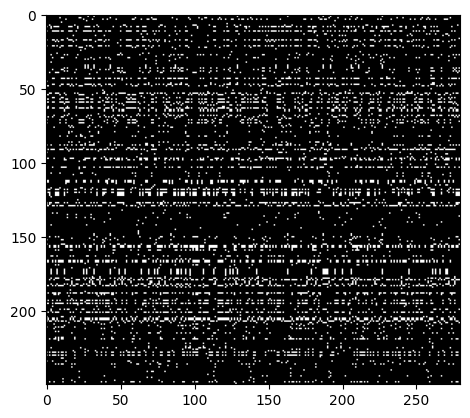

In [38]:
#Print the label and export an image from the training data, to visualize its appearance
print(y[1])
import matplotlib.pyplot as plt
plt.imshow(x[1,:,:,0],cmap='gray', vmin=-1, vmax=1)

In [13]:
#you can also visualize the array values (-1 for major and 1 to minor).
x[0,:,:,0]

array([[-1.,  1., -1., ..., -1., -1., -1.],
       [-1.,  1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1.,  1.],
       ...,
       [-1.,  1., -1., ..., -1.,  1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [ 1., -1., -1., ..., -1., -1.,  1.]])

In [ ]:
''''
# If you need to add missing data to the simulations, you can add it as 0s.
# The commands below will add missing data randomly in the simulated data.
# This is necessary when your real data contains missing genotypes and
# we need to train the network to be able to recognize it.

#Add missing data (coded as 0s) to the simulated matrices
# as a percentage according to the empirical data (15% in E. segueriana).
missD_perc = 15
missD = int(x.shape[1]*x.shape[2]*(missD_perc/100))
for i in range(x.shape[0]):
    indices_2d = np.random.choice(x.shape[1], size=missD, replace=True)
    indices_3d = np.random.choice(x.shape[2], size=missD, replace=True)
    x[i, indices_2d, indices_3d] = 0
del(missD)
'''

Now we need to separate the training simulations into the training and validation sets. Do you remember what are these sets used to? We don't need to define the test now, but do you remember what will it be used to?

We will also compile the architecture, define the optimzer and set an Early Stopping approach.

In [10]:
Y_train, Y_valid, X_train, X_valid = train_test_split(y,x,test_size=0.2, shuffle=True)
del(x)

In [11]:

# Create the CNN network.
model = create_cnn(np.transpose(X_train, (0, 2, 1, 3)))

# Compile the CNN.
model.compile(loss=keras.losses.categorical_crossentropy,
	              optimizer='Adam',
	              metrics=['accuracy'])

# We will use early stopping and save the model with the best val_accuracy.
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=25, verbose=0, mode='max', restore_best_weights=True)
### stop training when validation error increases (wait 25 epochs to see if there is any improvement).

# Check the architecture.
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 280, 250, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 280, 500)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 279, 256)       │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 139, 256)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 139, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 138, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 69, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 69, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,454,338 (5.55 MB)

 Trainable params: 1,453,570 (5.54 MB)

 Non-trainable params: 768 (3.00 KB)

  Cloning https://github.com/paulgavrikov/visualkeras to /tmp/pip-req-build-o_gsfmim
  Running command git clone --filter=blob:none --quiet https://github.com/paulgavrikov/visualkeras /tmp/pip-req-build-o_gsfmim
  Resolved https://github.com/paulgavrikov/visualkeras to commit b5234255cf8f85315da27d6c58a8adaff6f78da8
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.8 MB/s eta 0:00:00
  Created wheel for visualkeras: filename=visualkeras-0.2.0-py3-none-any.whl size=94072 sha256=8853c29328982013f2b2136ca6f890a5e544d05d2bb12445775723d07b73f5b5
  Stored in directory: /tmp/pip-ephem-wheel-cache-kyu43lqh/wheels/93/5c/60/e926df1ca6d69bb3f917bff798e0ea3d0a5a39ad739b1e4ed5
Successfully built visualkeras


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:820: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


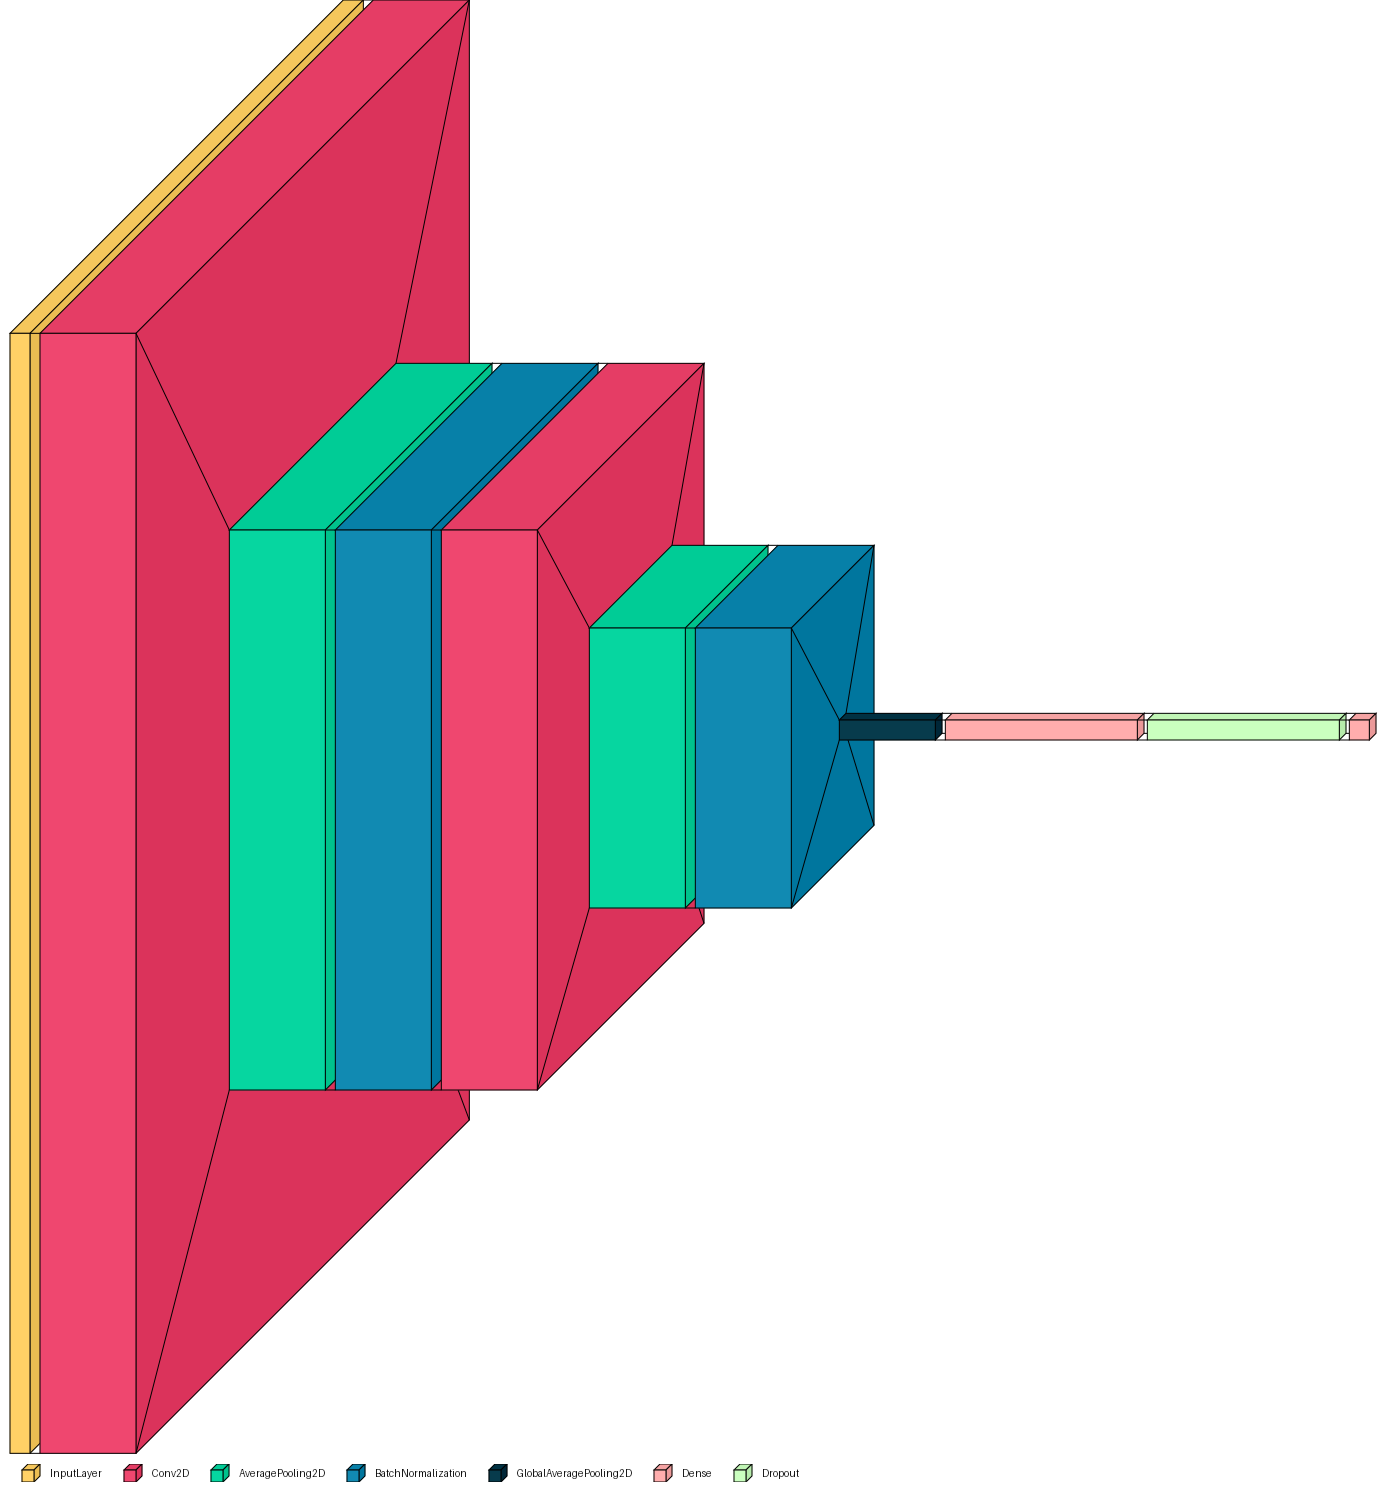

In [10]:
#We can also have a graphical visualization of the layers
!pip install git+https://github.com/paulgavrikov/visualkeras --upgrade
import visualkeras
from PIL import ImageFont
visualkeras.layered_view(model, legend=True)

No it's time to train the network. This will take some time. While it's training we can discuss the previous steps of the script.

In [12]:
#Run the CNN
history = model.fit(np.transpose(X_train, (0, 2, 1, 3)), Y_train, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(np.transpose(X_valid, (0, 2, 1, 3)), Y_valid),callbacks=[earlyStopping])

# Save the model.
model.save(filepath='Trained_Anopheles.acc.keras')

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.4881 - loss: 2.8125 - val_accuracy: 0.5025 - val_loss: 6.0808
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5994 - loss: 2.2993 - val_accuracy: 0.5150 - val_loss: 4.8275
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6837 - loss: 1.6594 - val_accuracy: 0.5075 - val_loss: 7.4958
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7856 - loss: 0.9307 - val_accuracy: 0.4975 - val_loss: 2.9497
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8325 - loss: 0.6595 - val_accuracy: 0.5425 - val_loss: 4.0244
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.8825 - loss: 0.4440 - val_accuracy: 0.5050 - val_loss: 5.7477
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8975 - loss: 0.3463 - val_accuracy: 0.5225 - val_loss: 4.8512
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9162 - loss: 0.2967 - val_accuracy: 

After training we need to evaluate if the network is learning and not overfitting. The next commands will plot the accuracy in the training and validation sets.

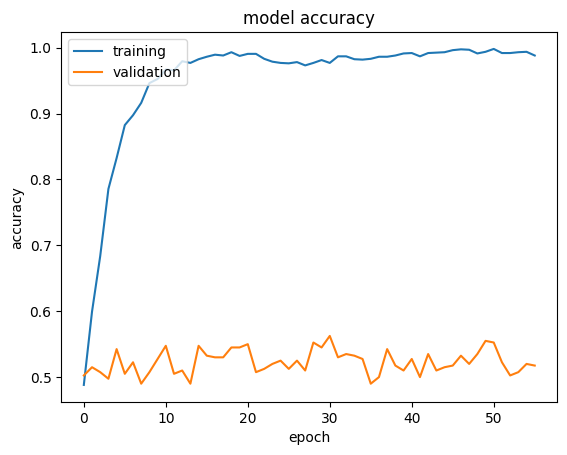

In [13]:
# Plot training and validation accuracies
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training', 'validation'], loc='upper left')
plt.show()

What do you think about this curves? Do you think that training was properly done? Can you think of ways to improve it?

## **Section 3: Perform cross validation predictions with another 100 simulations per model. Those were not seen by the network during training**

Now we are going to test the trained model using the test set. These are new simulations that were not used by the network during the training. The idea here is to use simulaiton as if they are our real data (we call this pseudoobserved data in ABC) and see what the network predicts for each of these simulations. After that we compare the predicted values with the real (simulated) ones.

200 200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step


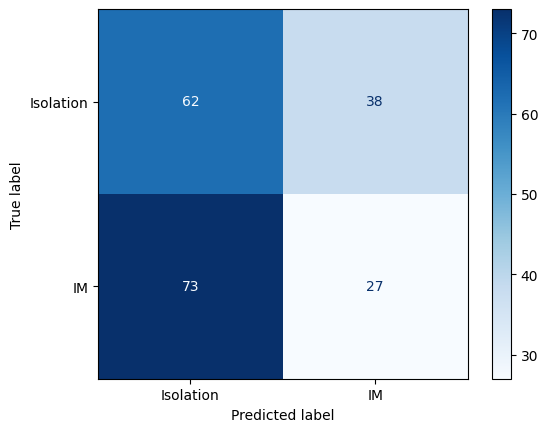

In [14]:
# Load Numpy test set arrays containing the test set simulations.
u1 = np.load("/content/simulations/testset/sims_nomig.npy",mmap_mode='r')
u2 = np.load("/content/simulations/testset/sims_im.npy",mmap_mode='r')

# Combine all test set arrays.
xtest=np.concatenate((u1,u2),axis=0)

xtest = polarize_genotypes(xtest)

# Label each simulated array.
ytest=[0 for i in range(len(u1))]
ytest.extend([1 for i in range(len(u2))])
ytest = np.array(ytest)

#delete temporary files to free memory.
del (u1,u2)

# Print label and simulations length, these should be the same.
print (len(xtest), len(ytest))

# Predict with the trained model and export a confusion matrix.
pred = model.predict(np.transpose(xtest, (0, 2, 1, 3)))
pred_cat = [i.argmax() for i in pred]
cm=confusion_matrix(ytest, pred_cat)
scenarios = ['Isolation', 'IM']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=scenarios)

disp.plot(cmap=plt.cm.Blues)
plt.show()

Please take a moment to analyze the confusion matrix. Can you detect which models are more difficult to predict? For those, what is the other model that is creating this confusion?

## **Section 4: Predict the most likely model for the empirical data, using the trained CNN.**

In [6]:
def process_genomic_hdf5(file_path, window_size=250, max_span=200_000,
                         stride=125, max_windows=1000, random_sample=True):
    all_extracted = []

    with h5py.File(file_path, "r") as f:
        # 1. Map out all possible windows first
        potential_starts = []
        for contig in ["3L", "3R"]:
            if contig in f:
                n_variants = f[contig]["genotypes"].shape[0]
                indices = [(contig, s) for s in range(0, n_variants - window_size, stride)]
                potential_starts.extend(indices)

        # 2. Toggle Randomization
        if random_sample:
            print(f"Randomly sampling {max_windows} windows...")
            random.shuffle(potential_starts)
        else:
            print(f"Sequentially extracting the first {max_windows} windows...")

        # 3. Extraction Loop
        for contig, start in potential_starts:
            if len(all_extracted) >= max_windows:
                break

            group = f[contig]
            pos = group["positions"]
            end = start + window_size

            # Skip windows crossing physical gaps
            if (pos[end-1] - pos[start]) > max_span:
                continue

            # Extract genotypes (variants, samples, ploidy) -> (variants, haplotypes)
            gt_win = group["genotypes"][start:end, :, :].reshape(window_size, -1)

            # Create Log-Distance Channel
            pos_win = pos[start:end]
            dist = np.diff(pos_win, append=pos_win[-1] + 1)
            log_dist = np.log1p(dist) # Natural log: $log(1 + \Delta pos)$

            # Match haplotype dimensions (e.g., 280)
            n_hap = gt_win.shape[1]
            dist_channel = np.tile(log_dist[:, np.newaxis], (1, n_hap))

            # Stack into (window_size, n_hap, 2)
            combined = np.stack([gt_win, dist_channel], axis=-1)
            all_extracted.append(combined)

    return np.array(all_extracted)

In [7]:
# Load empirical data.
infile=process_genomic_hdf5("/content/simulations/MalariaGEN_GN_BF_3L_3R.h5", random_sample=True)
inp=np.array(infile)

inp.shape

emp = polarize_genotypes(inp)

Randomly sampling 1000 windows...


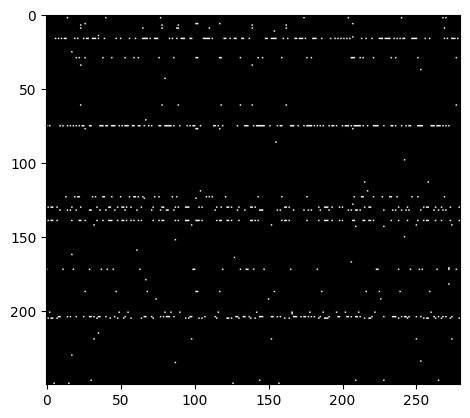

In [24]:
plt.imshow(emp[5,:,:,0],cmap='gray', vmin=-1, vmax=1)

In [18]:
# Predict model probabilities for each of the 1000 subsets.
Emp_pred = model.predict(np.transpose(emp, (0, 2, 1, 3)))

# Print for each subset
print(Emp_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[9.9999964e-01 3.1492257e-07]
 [9.4740683e-01 5.2593146e-02]
 [1.0000000e+00 1.5429010e-11]
 ...
 [1.0000000e+00 1.3603009e-13]
 [1.0000000e+00 5.9011636e-09]
 [9.9999416e-01 5.8253777e-06]]


In [19]:
Emp_pred.shape

(1000, 2)

In [20]:
# Print the average of all subsets
np.mean(Emp_pred, axis=0)


array([0.98557323, 0.01442728], dtype=float32)

/tmp/ipykernel_13096/3294942241.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_pred[col], label=col, shade=True)
/tmp/ipykernel_13096/3294942241.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_pred[col], label=col, shade=True)


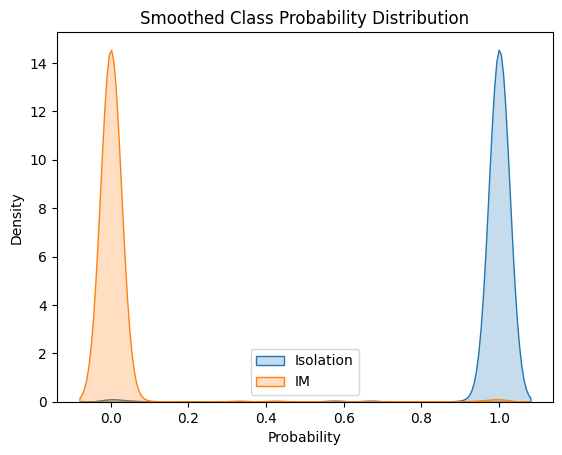

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Assuming Emp_pred is already defined as in the provided code

# Convert Emp_pred to a pandas DataFrame for easier manipulation
df_pred = pd.DataFrame(Emp_pred, columns=['Isolation', 'IM'])

# Calculate smoothed distributions (using kernel density estimation)
for col in df_pred.columns:
  sns.kdeplot(df_pred[col], label=col, shade=True)

plt.title('Smoothed Class Probability Distribution')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.legend()
plt.show()


## **Section 5: We can also perform parameter estimation.**

Now we can use the same architecture (with a slight difference in the last layer) to perform parameter estimation. To make things simple, we will focus only in the simulations under the selected scenario (model 2). We will also need to change the labels of each simulation to the parameter values used.

In [8]:
# Define the CNN architecture.
def create_cnn(xtrain):
    # Input shape: (250 SNPs, 280 Haplotypes, 2 Channels)input_shape = (xtrain.shape[1], xtrain.shape[2], xtrain.shape[3]) # (250, 280, 2)
    input_shape = (xtrain.shape[1], xtrain.shape[2], xtrain.shape[3])
    inputs = Input(shape=input_shape)

    # 1. THE FIX: Reshape (250, 280, 2) -> (250, 560)
    # This combines Haplotypes and Channels into one "feature" dimension for Conv1D
    x = Reshape((xtrain.shape[1], xtrain.shape[2] * xtrain.shape[3]))(inputs)

    # 2. Convolutional Layers
    x = Conv1D(256, kernel_size=2, activation='relu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Conv1D(128, kernel_size=2, activation='relu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    x = BatchNormalization()(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(numParams)(x)# This was the only change in the architecture.
    # Construct the CNN.
    model = Model(inputs, x)
    # Return the CNN.
    return model

In [13]:
X_train.shape

(800, 250, 280, 2)

In [15]:
# Load parameters.
Params_im = pd.read_csv('/content/simulations/mosquito-task2_im.csv', sep=",").dropna()
T_split_im = Params_im["T_split"]
y = np.array(T_split_im)
numParams=1

#Load simulations for the best model.
u2 = np.load("/content/simulations/sims_im.npy",mmap_mode='r')

x = np.array(u2)
x = polarize_genotypes(x)

# Print label and simulations length, these should be the same.
print (len(x), len(y))

Y_train, Y_valid, X_train, X_valid = train_test_split(y,x,test_size=0.2, shuffle=False)
del(x)

# Create the CNN network.
cnn = create_cnn(np.transpose(X_train, (0, 2, 1, 3)))

# Compile the CNN.
cnn.compile(loss='mean_squared_error', #the loss is now defined as the mean squared error, as we have continuous labels
	              optimizer='Adam')

# Check the architecture.
cnn.summary()

# Run the CNN with early stopping. Save the model with the best val_accuracy.
earlyStopping = EarlyStopping(monitor='val_loss', patience=25, verbose=0, mode='max', restore_best_weights=True)

history = cnn.fit(np.transpose(X_train, (0, 2, 1, 3)), Y_train, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(np.transpose(X_valid, (0, 2, 1, 3)), Y_valid),callbacks=[earlyStopping])

1000 1000


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 280, 250, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 280, 500)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 279, 256)       │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_4             │ (None, 139, 256)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 139, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 138, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_5             │ (None, 69, 128)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 69, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8832)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,130,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,454,209 (5.55 MB)

 Trainable params: 1,453,441 (5.54 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 378ms/step - loss: 88620.6562 - val_loss: 46470.2266
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 61564.2969 - val_loss: 213968.3594
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 22494.5605 - val_loss: 1000550.9375
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 9948.9854 - val_loss: 21985.3730
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7312.5718 - val_loss: 6140.8789
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 6299.7729 - val_loss: 15403.1113
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5719.5215 - val_loss: 8913.0908
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 5288.7925 - val_loss: 9379.6729
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 4723.1499 - val_loss: 11458.8809
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 5069.9224 - val_loss: 14726.7959
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 466

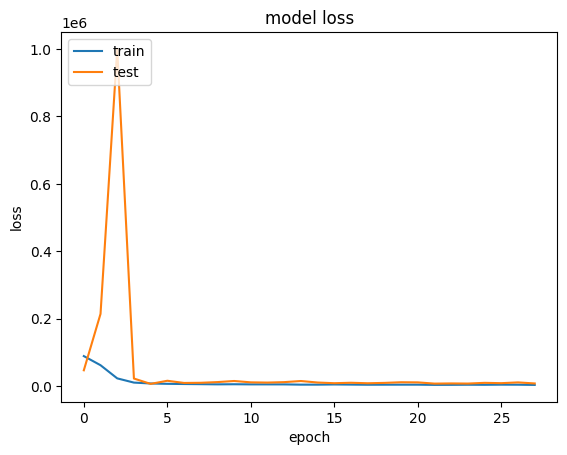

In [16]:
# Plot training and validation accuracies
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

##**Now let's predict the real data.**



In [19]:

# Create 1000 subsets containing 1,000 random SNPs from the full empirical data.
Emp_pred = cnn.predict(np.transpose(emp, (0, 2, 1, 3)))

Emp_pred * 10

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[2688.9507 ],
       [2772.392  ],
       [4950.1123 ],
       [5175.396  ],
       [4518.3154 ],
       [3293.272  ],
       [3286.2656 ],
       [3392.6282 ],
       [3019.8433 ],
       [2689.1523 ],
       [3511.1592 ],
       [5678.2764 ],
       [4107.041  ],
       [3679.3857 ],
       [5332.6567 ],
       [3350.1526 ],
       [4146.9395 ],
       [3731.626  ],
       [5367.2715 ],
       [3180.3696 ],
       [4609.392  ],
       [2938.6094 ],
       [3091.161  ],
       [4397.808  ],
       [2980.1216 ],
       [2182.2275 ],
       [3774.2605 ],
       [2205.2505 ],
       [4934.343  ],
       [3016.5845 ],
       [3679.0303 ],
       [5271.7373 ],
       [4394.219  ],
       [4319.9814 ],
       [4858.3193 ],
       [4155.2437 ],
       [3365.457  ],
       [3919.0527 ],
       [3536.4585 ],
       [4481.3564 ],
       [3843.651  ],
       [3555.7996 ],
       [5541.731  ],
       [1533.1416 ],
       [2352.0664 ],
       [4429.5674 ],
       [3815.7207 ],
       [3575.

In [20]:
#Print parameter values (averaged over subsets)
print(np.mean(Emp_pred * 10, axis=0))

[3804.6606]


# Task (Optional)

If you want you can compare the errors of your estimates using CNN and using summary statistics (ABC and Deep Learning). You just need to use the code from Day 2.